# Willingness-to-Pay & Price Elasticity Model

The core pricing question: **for a given shipment and customer, how does
the probability of winning the booking change as we move the price?**

We frame this as a supervised learning problem -- predict `accepted`
(0/1) from the quoted price (expressed relative to the competitor's
price) and shipment/customer context -- then read off a demand curve by
sweeping the price at prediction time. This is the standard "response
model" approach to WTP estimation, and it's what lets us turn a
classifier into a pricing decision.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import sys, os

sys.path.append(os.getcwd())
from config import DATA_DIR, FIG_DIR, CATEGORICAL, INK, SEGMENT_ORDER, RANDOM_SEED, set_style

set_style()
FIG_SUBDIR = os.path.join(FIG_DIR, "03_wtp")
os.makedirs(FIG_SUBDIR, exist_ok=True)

quotes = pd.read_csv(os.path.join(DATA_DIR, "quotes.csv"), parse_dates=["quote_date"])
customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"))[["customer_id", "contract_type"]]
quotes = quotes.merge(customers, on="customer_id", how="left")
print(f"quotes: {quotes.shape}, date range {quotes['quote_date'].min().date()} -> {quotes['quote_date'].max().date()}")

quotes: (92530, 14), date range 2019-01-20 -> 2026-08-19

## 1. Time-based train/test split

We hold out the most recent 6 months as a test set, mimicking how the
model would actually be validated before a production deploy: trained
on the past, evaluated on data it has never seen, with no shuffling
across time.

In [2]:
CUTOFF = quotes["quote_date"].max() - pd.DateOffset(months=6)
train = quotes[quotes["quote_date"] < CUTOFF].copy()
test = quotes[quotes["quote_date"] >= CUTOFF].copy()
print(f"Train: {train.shape[0]:,} quotes (< {CUTOFF.date()})  |  Test: {test.shape[0]:,} quotes (>= {CUTOFF.date()})")

num_features = ["price_ratio", "weight_kg", "distance_km", "competitor_price"]
cat_features = ["segment", "service_level", "mode", "contract_type"]
target = "accepted"

X_train, y_train = train[num_features + cat_features], train[target]
X_test, y_test = test[num_features + cat_features], test[target]

Train: 81,876 quotes (< 2026-02-19)  |  Test: 10,654 quotes (>= 2026-02-19)

## 2. Two models: an interpretable baseline and a gradient-boosted model

Logistic regression gives us a directly interpretable price coefficient
per segment (classic elasticity-model style). The gradient-boosted
model captures nonlinearities and interactions (e.g. price sensitivity
differing by service level) and should out-perform it on held-out AUC --
which is the case for using it in production instead of the simpler
model.

In [3]:
from sklearn.preprocessing import StandardScaler

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features),
])

logit_pipe = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))])
logit_pipe.fit(X_train, y_train)

gbm_pipe = Pipeline([("pre", pre), ("clf", HistGradientBoostingClassifier(
    max_depth=4, learning_rate=0.08, max_iter=300, random_state=RANDOM_SEED))])
gbm_pipe.fit(X_train, y_train)

results = {}
for name, model in [("Logistic Regression", logit_pipe), ("Gradient Boosting", gbm_pipe)]:
    p = model.predict_proba(X_test)[:, 1]
    results[name] = dict(
        auc=roc_auc_score(y_test, p),
        log_loss=log_loss(y_test, p),
        brier=brier_score_loss(y_test, p),
    )
results_df = pd.DataFrame(results).T
print(results_df.round(4))

                        auc  log_loss   brier
Logistic Regression  0.6055    0.2676  0.0707
Gradient Boosting    0.6051    0.2675  0.0707

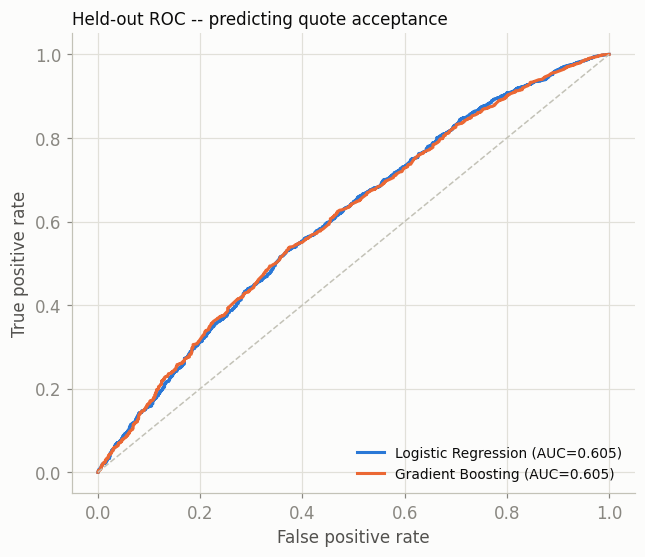

In [4]:
fig, ax = plt.subplots(figsize=(6, 5.2))
for i, (name, model) in enumerate([("Logistic Regression", logit_pipe), ("Gradient Boosting", gbm_pipe)]):
    p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=CATEGORICAL[i], linewidth=2,
            label=f"{name} (AUC={results[name]['auc']:.3f})")
ax.plot([0, 1], [0, 1], color=INK["baseline"], linestyle="--", linewidth=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Held-out ROC -- predicting quote acceptance", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "01_roc_curve.png"), bbox_inches="tight")
plt.show()

model = gbm_pipe  # use the stronger model going forward

## 3. Calibration

For a WTP model, calibrated probabilities matter more than raw
discrimination -- we're about to multiply `P(accept)` by price to get
expected revenue, so if the probabilities are systematically off, so is
every downstream pricing decision.

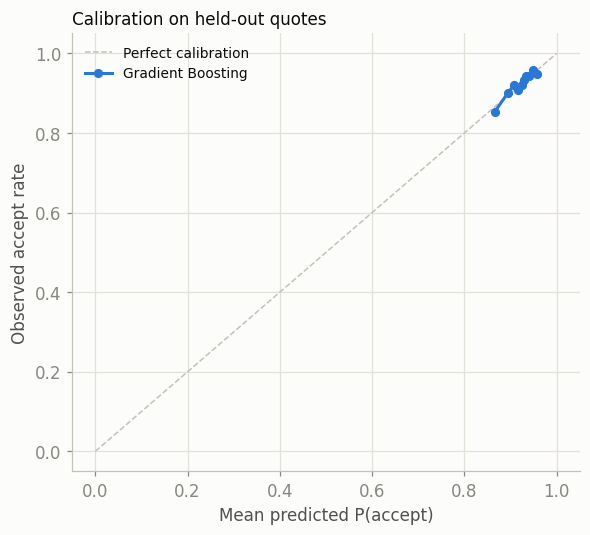

In [5]:
prob_true, prob_pred = calibration_curve(y_test, model.predict_proba(X_test)[:, 1], n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=INK["baseline"], linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(prob_pred, prob_true, marker="o", color=CATEGORICAL[0], linewidth=2, markersize=5, label="Gradient Boosting")
ax.set_xlabel("Mean predicted P(accept)")
ax.set_ylabel("Observed accept rate")
ax.set_title("Calibration on held-out quotes", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "02_calibration.png"), bbox_inches="tight")
plt.show()

## 4. Feature importance (permutation importance)

Rather than relying on impurity-based importances (biased toward
high-cardinality features), we use permutation importance on the
held-out set -- how much AUC drops when a feature is shuffled.

price_ratio         0.063920
segment             0.059974
competitor_price    0.001354
distance_km         0.001124
service_level       0.000735
weight_kg           0.000258
mode                0.000121
contract_type       0.000064
dtype: float64

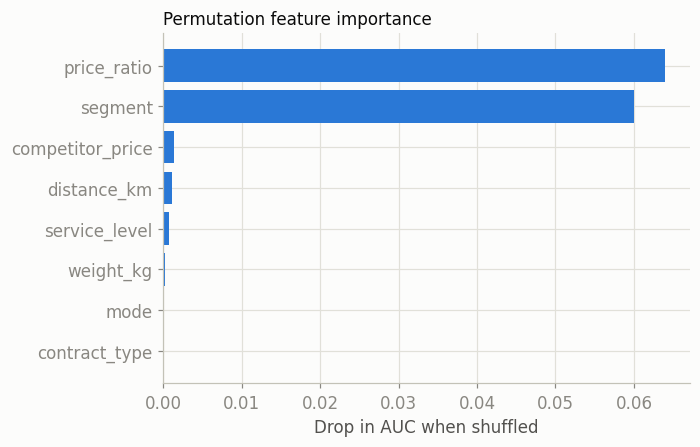

In [6]:
perm = permutation_importance(model, X_test, y_test, scoring="roc_auc",
                               n_repeats=8, random_state=RANDOM_SEED, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.barh(imp.index, imp.values, color=CATEGORICAL[0])
ax.set_xlabel("Drop in AUC when shuffled")
ax.set_title("Permutation feature importance", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "03_feature_importance.png"), bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False)

## 5. Elasticity curves by segment

We hold shipment characteristics at each segment's typical (median)
values and sweep `price_ratio` from 0.70 to 1.35x the competitor's
price, reading off the model's predicted acceptance probability. This
is the demand curve the pricing team actually wants to see.

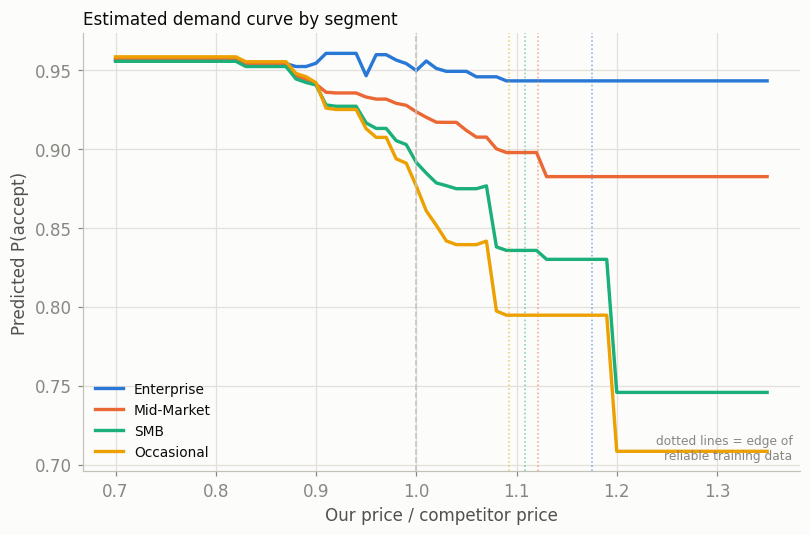

In [7]:
price_grid = np.linspace(0.70, 1.35, 66)
# A model can only be trusted where it had training data. Past the ~97th
# percentile of historically-observed price_ratio for a segment, very few
# quotes exist and a tree ensemble's predictions effectively flatten out
# (it can't extrapolate a trend it never saw) -- which would make an
# expected-revenue curve misleadingly keep climbing forever. We compute
# that per-segment support boundary and use it to cap what we'll act on.
support_upper = quotes.groupby("segment")["price_ratio"].quantile(0.97)

curves = {}
for seg in SEGMENT_ORDER:
    seg_rows = test[test["segment"] == seg]
    if len(seg_rows) == 0:
        seg_rows = train[train["segment"] == seg]
    typical = seg_rows[["weight_kg", "distance_km", "competitor_price"]].median()
    mode_mode = seg_rows["mode"].mode()[0]
    service_mode = seg_rows["service_level"].mode()[0]
    contract_mode = seg_rows["contract_type"].mode()[0]

    grid_df = pd.DataFrame({
        "price_ratio": price_grid,
        "weight_kg": typical["weight_kg"],
        "distance_km": typical["distance_km"],
        "competitor_price": typical["competitor_price"],
        "segment": seg,
        "service_level": service_mode,
        "mode": mode_mode,
        "contract_type": contract_mode,
    })
    grid_df["pred_accept_prob"] = model.predict_proba(grid_df[num_features + cat_features])[:, 1]
    grid_df["quoted_price"] = grid_df["price_ratio"] * typical["competitor_price"]
    grid_df["expected_revenue"] = grid_df["quoted_price"] * grid_df["pred_accept_prob"]
    grid_df["well_supported"] = grid_df["price_ratio"] <= support_upper[seg]
    curves[seg] = grid_df

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, seg in enumerate(SEGMENT_ORDER):
    c = curves[seg]
    ax.plot(c["price_ratio"], c["pred_accept_prob"], color=CATEGORICAL[i], linewidth=2.2, label=seg)
    ax.axvline(support_upper[seg], color=CATEGORICAL[i], linestyle=":", linewidth=1, alpha=0.6)
ax.axvline(1.0, color=INK["baseline"], linestyle="--", linewidth=1)
ax.set_xlabel("Our price / competitor price")
ax.set_ylabel("Predicted P(accept)")
ax.set_title("Estimated demand curve by segment", loc="left", fontsize=11)
ax.annotate("dotted lines = edge of\nreliable training data",
            xy=(0.99, 0.02), xycoords="axes fraction", ha="right", va="bottom",
            fontsize=8, color=INK["muted"])
ax.legend(frameon=False, fontsize=9, title=None, loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "04_elasticity_curves.png"), bbox_inches="tight")
plt.show()

## 6. Revenue-maximizing price point per segment

Multiplying the demand curve by price gives an expected-revenue curve
per quote; its argmax **within the well-supported price range** is the
price point that (in this simplified, single-quote view) maximizes
expected yield for a typical shipment in that segment. We deliberately
don't search past the training-data boundary -- if the curve is still
rising at that edge (as it is for Enterprise below), the honest
conclusion is "we can't yet tell where the optimum is; it would take a
deliberate pricing experiment at higher price points to find out",
not "raise the price indefinitely". This is the natural hand-off from a
WTP model to a pricing recommendation -- a full constrained
yield-optimization pass (jointly across the book, subject to
volume/competitiveness constraints) is the logical next step but is out
of scope for this demo.

   segment  current_avg_price_ratio  recommended_price_ratio  recommended_accept_prob  expected_revenue_at_recommendation  optimum_still_rising_at_data_edge  implied_price_move
Enterprise                    1.040                     1.17                    0.943                              139.03                               True            0.125000
Mid-Market                    0.987                     1.12                    0.898                              128.82                               True            0.134752
       SMB                    0.973                     1.07                    0.877                              120.69                              False            0.099692
Occasional                    0.957                     1.07                    0.842                              113.94                              False            0.118077

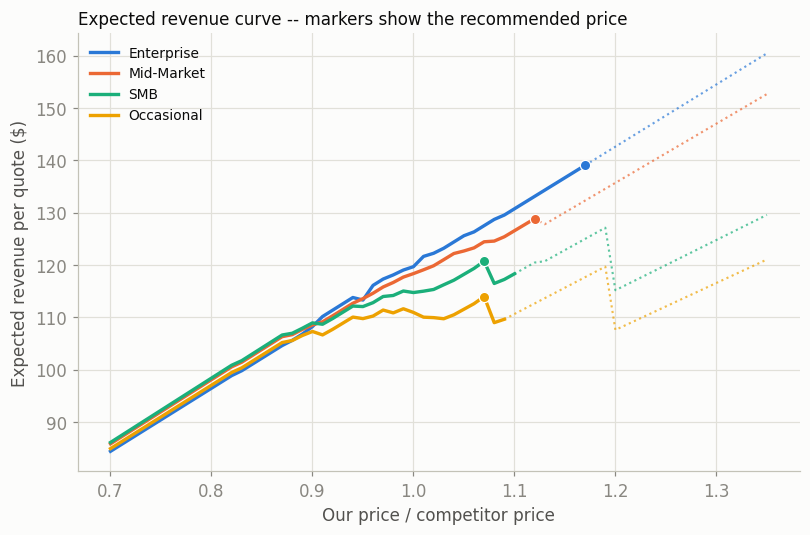

In [8]:
current_avg_ratio = quotes.groupby("segment")["price_ratio"].mean()
rows = []
for seg in SEGMENT_ORDER:
    c = curves[seg]
    supported = c[c["well_supported"]]
    best = supported.loc[supported["expected_revenue"].idxmax()]
    at_boundary = np.isclose(best["price_ratio"], supported["price_ratio"].max())
    rows.append({
        "segment": seg,
        "current_avg_price_ratio": round(current_avg_ratio[seg], 3),
        "recommended_price_ratio": round(best["price_ratio"], 3),
        "recommended_accept_prob": round(best["pred_accept_prob"], 3),
        "expected_revenue_at_recommendation": round(best["expected_revenue"], 2),
        "optimum_still_rising_at_data_edge": bool(at_boundary),
    })
recommendation = pd.DataFrame(rows)
recommendation["implied_price_move"] = (
    (recommendation["recommended_price_ratio"] / recommendation["current_avg_price_ratio"]) - 1
)
print(recommendation.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, seg in enumerate(SEGMENT_ORDER):
    c = curves[seg]
    supported, beyond = c[c["well_supported"]], c[~c["well_supported"]]
    ax.plot(supported["price_ratio"], supported["expected_revenue"],
            color=CATEGORICAL[i], linewidth=2.2, label=seg)
    if len(beyond):
        edge = c[c["well_supported"]].iloc[[-1]]
        beyond_plot = pd.concat([edge, beyond])
        ax.plot(beyond_plot["price_ratio"], beyond_plot["expected_revenue"],
                color=CATEGORICAL[i], linewidth=1.4, linestyle=":", alpha=0.7)
    best = recommendation[recommendation["segment"] == seg].iloc[0]
    ax.scatter([best["recommended_price_ratio"]], [best["expected_revenue_at_recommendation"]],
               color=CATEGORICAL[i], s=45, zorder=5, edgecolor="white", linewidth=0.8)
ax.set_xlabel("Our price / competitor price")
ax.set_ylabel("Expected revenue per quote ($)")
ax.set_title("Expected revenue curve -- markers show the recommended price", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "05_revenue_curves.png"), bbox_inches="tight")
plt.show()

## 7. Save

In [9]:
recommendation.to_csv(os.path.join(DATA_DIR, "wtp_price_recommendations.csv"), index=False)
results_df.to_csv(os.path.join(DATA_DIR, "wtp_model_metrics.csv"))
print("Saved wtp_price_recommendations.csv and wtp_model_metrics.csv")

Saved wtp_price_recommendations.csv and wtp_model_metrics.csv